# X-venue noise concordance

`frag.xvenue_noise_concord` — **Hold**. Same-day noise levels can move together without implying a tradable edge or FEI/Epps claim.


In [1]:
from pathlib import Path
import os
import json
import math
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = (Path(os.environ.get('ARES_MICROSTRUCTURE') or (Path.home() / 'srv' / 'ares-microstructure')) / 'research' / 'books' / 'mn_tuwrv')
OUT = BOOK / 'out'
FIGS = OUT / 'desk_synthesis' / 'figs'
sys.path.insert(0, str(BOOK.parents[2]))  # ares-microstructure root

def jload(rel):
    return json.loads((OUT / rel).read_text())

def show_fig(name, caption=None):
    p = FIGS / name
    if caption:
        display(Markdown(f'**{caption}** — `{p.relative_to(BOOK)}`'))
    if p.exists():
        display(Image(filename=str(p)))
    else:
        display(Markdown(f'*missing figure* `{p}` — run `scripts/build_notebook_figs.py`'))

bc = jload('blocker_close/blocker_close.json')
gc = jload('gap_close/gap_close.json')
mc = jload('monte_carlo/mc_summary.json')
p2 = jload('pass2/pass2_gates.json')
ep = jload('expand_panel/expand_panel.json')
dp = jload('depth_predict/depth_predict.json') if (OUT/'depth_predict'/'depth_predict.json').exists() else {}
print('BOOK', BOOK)
print('figs', sorted(p.name for p in FIGS.glob('*.png')))
print('expand n_ok', ep['coverage']['n_ok'], 'depth keys', list(dp.keys())[:8])


BOOK /home/dev/srv/ares-microstructure/research/books/mn_tuwrv
figs ['fig_clock_medians.png', 'fig_gate_counts.png', 'fig_info_heatmap.png', 'fig_mc_rmse_ladder.png', 'fig_mid_venue_split.png', 'fig_noise_acf_lag1.png', 'fig_noise_vs_spread.png', 'fig_noise_vs_spread_gap_close.png', 'fig_pred_board.png', 'fig_pred_ic_noise.png', 'fig_ratio_hist.png', 'fig_signature.png', 'fig_tob_coverage.png', 'fig_tod_acf.png', 'fig_tsrv_oos.png', 'fig_venue_mid_taxonomy.png', 'signal_board.png']
expand n_ok 204 depth keys ['meta', 'information', 'predictive', 'taxonomy', 'tape_depth', 'uses', 'figures', 'decisions_rollup']


pass2 xvenue gate: {'decision': 'Hold', 'why': 'close_noise_days=5/6 (rel range <35%)'}


,day,symbol,venue,noise_std
0,2026-08-28,ETH,hyperliquid,0.000037
1,2026-08-28,ETH,deribit,0.000071
2,2026-08-28,ETH,kraken,0.000074
3,2026-08-29,ETH,hyperliquid,0.000048
4,2026-08-29,ETH,deribit,0.000021
5,2026-08-30,ETH,hyperliquid,0.000083
6,2026-08-30,ETH,deribit,0.000053
7,2026-08-31,ETH,hyperliquid,0.000055
8,2026-08-31,ETH,deribit,0.000052
9,2026-09-01,ETH,hyperliquid,0.000083


,day,symbol,n_venues,rel_range,ns_hyperliquid,ns_deribit,ns_kraken
0,2026-08-28,BTC,3,0.747888,0.000111,0.000076,0.000054
1,2026-08-28,ETH,3,0.520220,0.000037,0.000071,0.000074
2,2026-08-28,SOL,3,0.185073,0.000152,0.000129,0.000128
3,2026-08-29,BTC,2,0.741990,0.000042,0.000019,NaN
4,2026-08-29,ETH,2,0.766286,0.000048,0.000021,NaN
...,...,...,...,...,...,...,...
74,2026-09-29,BTC,3,0.347992,0.000020,0.000028,0.000025
75,2026-09-29,ETH,3,0.330193,0.000028,0.000039,0.000034
76,2026-09-29,SOL,2,0.301363,NaN,0.000068,0.000050
77,2026-09-30,BTC,2,0.194404,0.000044,0.000053,NaN


frac rel_range < 0.35: 0.6329113924050633


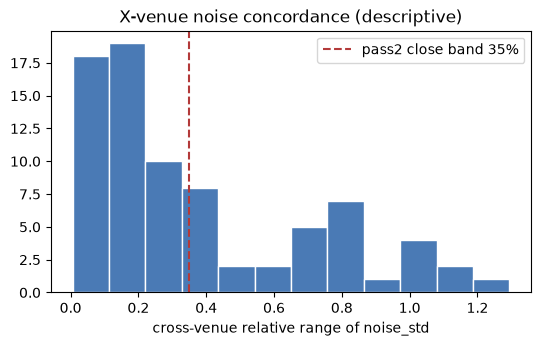

# X-venue noise — EXP_REPORT (Pass 2.5)

- Close-noise symbol-days: 26/28
- `frag.xvenue_noise_concord` → **Hold** (level concordance ≠ edge).



In [2]:
print('pass2 xvenue gate:', p2.get('frag.xvenue_noise_concord'))
# same-day noise concordance from blocker panel
rows = [r for r in bc['rows'] if r.get('ok')]
# pivot noise_std by day×symbol if calendar present
recs = []
for r in rows:
    ns = (r.get('calendar') or {}).get('noise_std', np.nan)
    if np.isfinite(ns):
        recs.append({'day': r['day'], 'symbol': r['symbol'], 'venue': r['venue'], 'noise_std': ns})
df = pd.DataFrame(recs)
display(df.head(20))
# pairwise day concordance: relative range across venues
conc = []
for (day, sym), g in df.groupby(['day','symbol']):
    if g['venue'].nunique() < 2:
        continue
    vals = g['noise_std'].to_numpy()
    rel = (vals.max() - vals.min()) / max(np.median(vals), 1e-12)
    conc.append({'day': day, 'symbol': sym, 'n_venues': int(g['venue'].nunique()), 'rel_range': float(rel),
                 **{f"ns_{r.venue}": float(r.noise_std) for r in g.itertuples()}})
cdf = pd.DataFrame(conc)
display(cdf)
if len(cdf):
    print('frac rel_range < 0.35:', float((cdf['rel_range'] < 0.35).mean()))
    fig, ax = plt.subplots(figsize=(6.2,3.4))
    ax.hist(cdf['rel_range'], bins=12, color='#4a7ab5', edgecolor='white')
    ax.axvline(0.35, color='#b33a3a', ls='--', label='pass2 close band 35%')
    ax.set_xlabel('cross-venue relative range of noise_std'); ax.legend()
    ax.set_title('X-venue noise concordance (descriptive)')
    plt.show()
print((BOOK/'chapters/xvenue_noise/EXP_REPORT.md').read_text()[:1500])
